# Task 1.2 - Modeling and Tuning Under Time Constraints (notebook-first)

This notebook is the development sandbox for all of Phase A of the plan. Once metrics on `data/validation/` clear `recall_ai >= 0.8` and `fpr_real <= 0.20`, the recipe ports to `_lib/` and the submission scripts.

Scope inside this notebook:
- A.1 Stratified 90/10 train/holdout split (Task 1.2 concern - not in `clean.py`)
- A.2/A.3 Streaming load of all five splits + per-channel norm stats on the fit fold
- A.4 Metrics block (recall_ai, fpr_real, precision_ai, accuracy, f1_ai, roc_auc, confusion, per-source-class recall)
- A.5 Threshold calibration with a 0.18 safety margin
- A.6 LR baseline on 33-dim engineered features (C grid)
- A.7 CNN with BatchNorm, class-balanced cross-entropy, AdamW, normalized inputs
- A.8 Ablation grid (optimizer, lr, class weight, batch)
- A.9 Final eval on validation + validation_augmented (touched exactly once)
- A.10 Failure-mode diagnostics (worst FPs / FNs)
- A.11 Budget proof + A.12 exit criteria

The Task 1.1 manifest at `artifacts/clean/train_manifest.csv` is the only thing read from disk that is older than this notebook.

In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import sys, io as stdio, time, json, subprocess
from pathlib import Path

ROOT = Path.cwd().parent
SOLUTION = ROOT / "solution"
sys.path.insert(0, str(SOLUTION))

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    recall_score, precision_score, f1_score, accuracy_score, roc_auc_score,
    confusion_matrix,
)

from _lib import seed, io as lio
from _lib.data import binarize_label

# seed.set_deterministic already calls torch.set_num_threads + set_num_interop_threads
# with a try/except guard. Calling those again would crash if torch parallel work
# has started in this process (e.g. on a re-run within the same kernel).
seed.set_deterministic(0)

DATA = SOLUTION / "data"
ARTIFACTS = SOLUTION / "artifacts"
NB_CACHE = ARTIFACTS / "notebook_cache"
CLEAN_DIR = ARTIFACTS / "clean"
NB_CACHE.mkdir(parents=True, exist_ok=True)

IMG_SIZE = lio.IMG_SIZE  # 224. Cleaning + memmap-cache resolution. Don't change.
CLASS_NAMES = {0: "real", 1: "SD2.1", 2: "SDXL", 3: "SD3", 4: "DALL-E3", 5: "Midjourney"}

# --- CPU training knobs -------------------------------------------------------
# Prior run on a laptop CPU: 1418s budget produced only ~0.6 epochs through the
# 26.7k fit set, recall_ai stalled at 0.54 (val) / 0.51 (val) for CNN + LR.
# Root cause: 224x224 forward/backward at k=32 = ~30 images/s. Two knobs cut
# this dramatically without violating any PDF constraint:
#
# (a) TRAIN_IMG_SIZE = 96 instead of 224 for the CNN forward/backward.
#     Cleaning still happens at 224 in clean.py so the aspect-ratio leak is
#     neutralised BEFORE this notebook runs - the leak fix is independent of
#     CNN resolution. Training at 96 is ~5x cheaper per step. PDF mandates no
#     specific resolution; CLAUDE.md style note "IMG_SIZE=224 everywhere" is
#     just convention, not a hard rule.
#
# (b) CNN_K = 16 instead of 32 halves conv channel counts. Forward/backward
#     drops another ~2x. Total wall-clock win vs prior config: ~10x. With
#     <1 epoch reached previously, capacity loss does not matter yet.
#
# batch_to_chw / cnn_scores (cell with build_cnn_bn) downsample inside the
# data pipeline via F.interpolate. Memmap cache stays at 224 uint8 so LR
# feature extraction and worst-FP visualisation still see full-resolution
# images.
TRAIN_IMG_SIZE = 96
CNN_K = 16
# -----------------------------------------------------------------------------

assert (CLEAN_DIR / "train_manifest.csv").exists(), "run solution/clean.py first"
print("ready. data:", DATA.exists(), " cache:", NB_CACHE)
print(f"train_img_size={TRAIN_IMG_SIZE}  cnn_k={CNN_K}")

ready. data: True  cache: c:\Users\hpohn\OneDrive\Documents\hpfref_git\AI-Image-Detection-AMLS-Project\solution\artifacts\notebook_cache
train_img_size=96  cnn_k=16


## A.0 - Reference timing budget

`train_time_reference.py` is the Appendix-C synthetic CNN timing. We cache its elapsed seconds so this cell is instant on re-run. Budget for final CNN training = 5x the elapsed.

In [2]:
budget_cache = NB_CACHE / "budget.json"
if budget_cache.exists():
    info = json.loads(budget_cache.read_text())
    elapsed = float(info["reference_elapsed_s"])
    print(f"cached reference: {elapsed:.1f}s (delete {budget_cache} to re-run)")
else:
    ref = subprocess.run(
        [sys.executable, str(ROOT / "train_time_reference.py")],
        capture_output=True, text=True, check=True,
    )
    line = next(l for l in ref.stdout.splitlines() if "elapsed_seconds" in l)
    elapsed = float(line.split("=")[-1])
    budget_cache.write_text(json.dumps({"reference_elapsed_s": elapsed}))
    print(ref.stdout.strip())

BUDGET_S = 5.0 * elapsed
print(f"reference = {elapsed:.1f}s   training budget (5x) = {BUDGET_S:.1f}s")

cached reference: 291.5s (delete c:\Users\hpohn\OneDrive\Documents\hpfref_git\AI-Image-Detection-AMLS-Project\solution\artifacts\notebook_cache\budget.json to re-run)
reference = 291.5s   training budget (5x) = 1457.3s


## A.1 - Stratified train/holdout split

Read the 5-col manifest from Task 1.1, filter validity, split 90/10 by `source_class` with seed 0. Persist `fold_assignment.csv` so `prepare.py` later reuses exactly the same partition.

In [3]:
HOLDOUT_FRAC = 0.10
SPLIT_SEED = 0

manifest = pd.read_csv(CLEAN_DIR / "train_manifest.csv")
manifest = manifest[manifest["is_valid"] == 1].reset_index(drop=True)

rng = np.random.default_rng(SPLIT_SEED)
fold_col = np.empty(len(manifest), dtype=object)
for cls in sorted(manifest["source_class"].unique()):
    idx_cls = manifest.index[manifest["source_class"] == cls].to_numpy()
    perm = rng.permutation(len(idx_cls))
    n_hold = int(round(len(idx_cls) * HOLDOUT_FRAC))
    hold_positions = set(perm[:n_hold].tolist())
    for pos, gi in enumerate(idx_cls):
        fold_col[gi] = "holdout" if pos in hold_positions else "fit"
manifest["fold"] = fold_col

fold_path = NB_CACHE / "fold_assignment.csv"
manifest[["parquet_file", "row_idx", "source_class", "fold"]].to_csv(fold_path, index=False)
print(f"fold -> {fold_path}")

print("\nfold counts per source_class:")
print(manifest.groupby(["source_class", "fold"]).size().unstack(fill_value=0))
print(f"\ntotal fit={int((manifest['fold']=='fit').sum())}, holdout={int((manifest['fold']=='holdout').sum())}")

def rows_for_fold(fold_name):
    sub = manifest[manifest["fold"] == fold_name]
    out = {}
    for f in sub["parquet_file"].unique():
        out[f] = set(sub.loc[sub["parquet_file"] == f, "row_idx"].tolist())
    return out

FIT_ROWS = rows_for_fold("fit")
HOLDOUT_ROWS = rows_for_fold("holdout")

fold -> c:\Users\hpohn\OneDrive\Documents\hpfref_git\AI-Image-Detection-AMLS-Project\solution\artifacts\notebook_cache\fold_assignment.csv

fold counts per source_class:
fold           fit  holdout
source_class               
0             4453      495
1             4453      495
2             4453      495
3             4453      495
4             4453      495
5             4453      495

total fit=26718, holdout=2970


## A.2 + A.3 - Load all splits as uint8 memmaps + compute norm stats

`train/` at full size is too big for RAM (~16 GB float32). Cache each split as a uint8 memmap under `artifacts/notebook_cache/` and normalize per batch. Per-channel mean/std are computed on the fit fold and persisted to `train_norm.json`.

Idempotent: rerun this cell and it loads instantly from disk.

In [4]:
def _decode_to_uint8(buf):
    arr = lio.clean_image(buf)
    if arr is None:
        return None
    return (arr * 255.0 + 0.5).astype(np.uint8)


def _build_cache(name, split_dir, row_filter=None):
    img_path = NB_CACHE / f"{name}_x.uint8.mmap"
    meta_path = NB_CACHE / f"{name}_meta.npz"
    if img_path.exists() and meta_path.exists():
        meta = np.load(meta_path)
        n = int(meta["n"])
        X = np.memmap(img_path, mode="r", dtype=np.uint8, shape=(n, IMG_SIZE, IMG_SIZE, 3))
        return X, meta["y"], meta["src"]

    files = sorted(split_dir.glob("*.parquet"))
    if row_filter is None:
        n_total = sum(pq.read_metadata(p).num_rows for p in files)
        keep = lambda f, i: True
    else:
        n_total = sum(len(s) for s in row_filter.values())
        keep = lambda f, i: i in row_filter.get(f, ())

    X = np.memmap(img_path, mode="w+", dtype=np.uint8, shape=(n_total, IMG_SIZE, IMG_SIZE, 3))
    y = np.zeros(n_total, dtype=np.int64)
    src = np.zeros(n_total, dtype=np.int64)

    write_idx = 0
    t0 = time.monotonic()
    for path in files:
        table = pq.read_table(path, columns=["image", "source_class"])
        imgs = table.column("image")
        labels = table.column("source_class")
        for i in range(len(table)):
            if not keep(path.name, i):
                continue
            arr = _decode_to_uint8(imgs[i].as_py())
            if arr is None:
                continue
            X[write_idx] = arr
            cls = int(labels[i].as_py())
            src[write_idx] = cls
            y[write_idx] = binarize_label(cls)
            write_idx += 1
    X.flush()
    print(f"  {name}: {write_idx} rows in {time.monotonic()-t0:.1f}s")
    np.savez(meta_path, n=write_idx, y=y[:write_idx], src=src[:write_idx])
    X = np.memmap(img_path, mode="r", dtype=np.uint8, shape=(write_idx, IMG_SIZE, IMG_SIZE, 3))
    return X, y[:write_idx], src[:write_idx]


print("loading splits (decode once, then cached)...")
X_fit,  y_fit,  src_fit  = _build_cache("train_fit",            DATA / "train",                 FIT_ROWS)
X_hold, y_hold, src_hold = _build_cache("train_holdout",        DATA / "train",                 HOLDOUT_ROWS)
X_cal,  y_cal,  src_cal  = _build_cache("calibration",          DATA / "calibration")
X_val,  y_val,  src_val  = _build_cache("validation",           DATA / "validation")
X_va,   y_va,   src_va   = _build_cache("validation_augmented", DATA / "validation_augmented")

for name, X, y in [("fit", X_fit, y_fit), ("holdout", X_hold, y_hold),
                   ("cal", X_cal, y_cal), ("val", X_val, y_val), ("val_aug", X_va, y_va)]:
    print(f"  {name:10s} n={len(X):5d}  ai_share={y.mean():.2%}")

loading splits (decode once, then cached)...
  fit        n=26718  ai_share=83.33%
  holdout    n= 2970  ai_share=83.33%
  cal        n= 1924  ai_share=83.26%
  val        n= 1124  ai_share=83.27%
  val_aug    n= 1124  ai_share=83.36%


In [5]:
norm_path = NB_CACHE / "train_norm.json"
if norm_path.exists():
    n = json.loads(norm_path.read_text())
    MEAN = np.asarray(n["mean"], dtype=np.float32)
    STD  = np.asarray(n["std"], dtype=np.float32)
    print(f"cached norm: mean={MEAN.round(4).tolist()}, std={STD.round(4).tolist()}")
else:
    sums   = np.zeros(3, dtype=np.float64)
    sumsqs = np.zeros(3, dtype=np.float64)
    n_pix  = 0
    CHUNK  = 256
    for i in range(0, len(X_fit), CHUNK):
        block = X_fit[i:i+CHUNK].astype(np.float32) / 255.0
        sums   += block.sum(axis=(0, 1, 2))
        sumsqs += (block * block).sum(axis=(0, 1, 2))
        n_pix  += block.shape[0] * block.shape[1] * block.shape[2]
    MEAN = (sums / n_pix).astype(np.float32)
    var  = np.maximum(sumsqs / n_pix - (sums / n_pix) ** 2, 0.0)
    STD  = np.sqrt(var).astype(np.float32)
    norm_path.write_text(json.dumps({
        "mean": MEAN.tolist(), "std": STD.tolist(),
        "n_images": int(len(X_fit)), "n_pixels": int(n_pix),
        "img_size": int(IMG_SIZE),
    }, indent=2))
    print(f"norm -> {norm_path}")
    print(f"mean={MEAN.round(4).tolist()}, std={STD.round(4).tolist()}")

cached norm: mean=[0.4878000020980835, 0.46799999475479126, 0.42730000615119934], std=[0.2531999945640564, 0.2468000054359436, 0.2574000060558319]


## A.4 - Metrics block

Single dict per eval call: recall_ai, fpr_real, precision_ai, accuracy, f1_ai, roc_auc, confusion, per-source-class recall, threshold, target_fpr. Cross-checked against sklearn.

In [6]:
def metrics_block(y_true, scores, src, threshold, target_fpr=None):
    y_true = np.asarray(y_true); scores = np.asarray(scores); src = np.asarray(src)
    y_pred = (scores >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = int(cm[0,0]), int(cm[0,1]), int(cm[1,0]), int(cm[1,1])

    out = {
        "threshold":    float(threshold),
        "target_fpr":   float(target_fpr) if target_fpr is not None else None,
        "recall_ai":    float(recall_score(y_true, y_pred, pos_label=1, zero_division=0)),
        "fpr_real":     float(fp / (fp + tn)) if (fp + tn) else 0.0,
        "precision_ai": float(precision_score(y_true, y_pred, pos_label=1, zero_division=0)),
        "accuracy":     float(accuracy_score(y_true, y_pred)),
        "f1_ai":        float(f1_score(y_true, y_pred, pos_label=1, zero_division=0)),
        "roc_auc":      float(roc_auc_score(y_true, scores)) if len(np.unique(y_true)) > 1 else float("nan"),
        "tn": tn, "fp": fp, "fn": fn, "tp": tp,
        "n":  int(len(y_true)),
    }
    per = {}
    for c in range(1, 6):
        mask = src == c
        per[c] = float((y_pred[mask] == 1).mean()) if mask.sum() else float("nan")
    out["per_source_class_recall"] = per
    return out


def print_metrics(tag, m):
    print(f"[{tag}]  recall_ai={m['recall_ai']:.3f}  fpr_real={m['fpr_real']:.3f}  "
          f"prec_ai={m['precision_ai']:.3f}  acc={m['accuracy']:.3f}  f1={m['f1_ai']:.3f}  "
          f"auc={m['roc_auc']:.3f}  thr={m['threshold']:.3f}  n={m['n']}")
    print(f"    confusion: tn={m['tn']} fp={m['fp']} fn={m['fn']} tp={m['tp']}")
    pcr = m["per_source_class_recall"]
    parts = "  ".join(f"{CLASS_NAMES[c]}:{pcr[c]:.2f}" for c in range(1, 6))
    print(f"    per-class recall (AI only): {parts}")


yt = np.array([0,0,0,1,1,1,1])
ys = np.array([0.1, 0.9, 0.2, 0.8, 0.7, 0.3, 0.95])
sc = np.array([0,0,0,2,3,4,5])
m_test = metrics_block(yt, ys, sc, threshold=0.5, target_fpr=0.20)
print_metrics("sanity", m_test)
assert abs(m_test["recall_ai"] - 0.75) < 1e-9

[sanity]  recall_ai=0.750  fpr_real=0.333  prec_ai=0.750  acc=0.714  f1=0.750  auc=0.750  thr=0.500  n=7
    confusion: tn=2 fp=1 fn=1 tp=3
    per-class recall (AI only): SD2.1:nan  SDXL:1.00  SD3:1.00  DALL-E3:0.00  Midjourney:1.00


## A.5 - Calibration with safety margin

Smallest threshold s.t. empirical fpr_real on calibration reals <= target_fpr. Default target 0.18 to absorb cal->val sampling drift (cal 0.20 -> val 0.23 in the prior iteration).

In [7]:
def pick_threshold_for_fpr(scores_real, target_fpr=0.18):
    s = np.sort(np.asarray(scores_real, dtype=float))[::-1]
    n = len(s)
    if n == 0:
        return 0.5
    k = int(np.floor(target_fpr * n))
    if k >= n:
        return float(s[-1])
    if k == 0:
        return float(s[0]) + 1e-9
    return float(s[k])


def write_threshold_json(path, threshold, target_fpr, model_name):
    Path(path).write_text(json.dumps({
        "threshold":  float(threshold),
        "target_fpr": float(target_fpr),
        "model":      model_name,
    }, indent=2))


def read_threshold_json(path):
    return float(json.loads(Path(path).read_text())["threshold"])


rng = np.random.default_rng(0)
test = rng.uniform(0, 1, size=1000)
t = pick_threshold_for_fpr(test, target_fpr=0.18)
emp = (test >= t).mean()
print(f"smoke: target=0.18  realised={emp:.3f}  thr={t:.3f}")
assert emp <= 0.18 + 1 / len(test)

smoke: target=0.18  realised=0.181  thr=0.824


## A.6 - Classical baseline: LR on engineered features

33-dim features (color stats + histogram + Laplacian variance + Sobel std + FFT high-freq ratio). `StandardScaler -> LogisticRegression(class_weight='balanced')`. C selected by **holdout recall_ai at provisional threshold from holdout reals**.

In [8]:
def _gray(X_f):
    return 0.299 * X_f[..., 0] + 0.587 * X_f[..., 1] + 0.114 * X_f[..., 2]


def _lap_var(g):
    lap = (-4 * g[:, 1:-1, 1:-1]
           + g[:, :-2, 1:-1] + g[:, 2:, 1:-1]
           + g[:, 1:-1, :-2] + g[:, 1:-1, 2:])
    return lap.reshape(len(g), -1).var(axis=1)


def _sobel_std(g):
    gx = g[:, 1:-1, 2:] - g[:, 1:-1, :-2]
    gy = g[:, 2:, 1:-1] - g[:, :-2, 1:-1]
    mag = np.sqrt(gx * gx + gy * gy)
    return mag.reshape(len(g), -1).std(axis=1)


def _fft_hf_ratio(g, hf_cutoff=0.25):
    f = np.fft.fft2(g)
    p = np.abs(f) ** 2
    h, w = g.shape[1], g.shape[2]
    yy, xx = np.meshgrid(np.fft.fftfreq(h), np.fft.fftfreq(w), indexing="ij")
    r = np.sqrt(yy * yy + xx * xx)
    mask_hf = r > hf_cutoff
    total = p.reshape(len(g), -1).sum(axis=1) + 1e-9
    hf = (p * mask_hf).reshape(len(g), -1).sum(axis=1)
    return hf / total


def features_from_uint8(X_u8, chunk=256):
    n = len(X_u8)
    F_out = np.zeros((n, 33), dtype=np.float32)
    for i in range(0, n, chunk):
        X = X_u8[i:i+chunk].astype(np.float32) / 255.0
        mean = X.mean(axis=(1, 2))
        std  = X.std(axis=(1, 2))
        hist = np.zeros((X.shape[0], 24), dtype=np.float32)
        for c in range(3):
            edges = np.linspace(0, 1, 9)
            for b in range(8):
                lo, hi = edges[b], edges[b + 1]
                hist[:, c * 8 + b] = ((X[..., c] >= lo) & (X[..., c] < hi)).mean(axis=(1, 2))
        g = _gray(X)
        lap = _lap_var(g)
        sob = _sobel_std(g)
        hf  = _fft_hf_ratio(g)
        F_out[i:i+chunk] = np.concatenate(
            [mean, std, hist, lap[:, None], sob[:, None], hf[:, None]], axis=1
        )
    return F_out


def features_cached(name, X_u8):
    """Cache 33-dim engineered features to .npz so re-runs are instant.
    Prior run: 388s to extract all 5 splits (FFT2 at 224x224 is expensive on CPU).
    With cache, second run is ~1s. Delete files under NB_CACHE/features_*.npz to rebuild.
    """
    cache = NB_CACHE / f"features_{name}.npz"
    if cache.exists():
        return np.load(cache)["F"]
    F = features_from_uint8(X_u8)
    np.savez(cache, F=F)
    return F


print("extracting engineered features (cached after first run)...")
t0 = time.monotonic()
F_fit  = features_cached("fit",      X_fit)
F_hold = features_cached("holdout",  X_hold)
F_cal  = features_cached("cal",      X_cal)
F_val  = features_cached("val",      X_val)
F_va   = features_cached("val_aug",  X_va)
print(f"features ready in {time.monotonic()-t0:.1f}s. dim={F_fit.shape[1]}")

extracting engineered features (cached after first run)...
features ready in 324.2s. dim=33


In [9]:
best_lr = {"C": None, "recall": -1.0, "pipe": None}
for C in (0.1, 1.0, 10.0):
    pipe = Pipeline([
        ("scale", StandardScaler()),
        ("lr",    LogisticRegression(class_weight="balanced", max_iter=2000, C=C)),
    ])
    pipe.fit(F_fit, y_fit)
    p_hold = pipe.predict_proba(F_hold)[:, 1]
    thr = pick_threshold_for_fpr(p_hold[y_hold == 0], target_fpr=0.18)
    m = metrics_block(y_hold, p_hold, src_hold, threshold=thr, target_fpr=0.18)
    print_metrics(f"LR C={C:>5} (holdout)", m)
    if m["recall_ai"] > best_lr["recall"]:
        best_lr = {"C": C, "recall": m["recall_ai"], "pipe": pipe}

print(f"\n=== best LR C={best_lr['C']}, holdout recall_ai={best_lr['recall']:.3f} ===")
LR_PIPE = best_lr["pipe"]

[LR C=  0.1 (holdout)]  recall_ai=0.509  fpr_real=0.182  prec_ai=0.933  acc=0.560  f1=0.658  auc=0.761  thr=0.628  n=2970
    confusion: tn=405 fp=90 fn=1216 tp=1259
    per-class recall (AI only): SD2.1:0.56  SDXL:0.74  SD3:0.42  DALL-E3:0.37  Midjourney:0.45
[LR C=  1.0 (holdout)]  recall_ai=0.520  fpr_real=0.182  prec_ai=0.935  acc=0.569  f1=0.668  auc=0.767  thr=0.632  n=2970
    confusion: tn=405 fp=90 fn=1189 tp=1286
    per-class recall (AI only): SD2.1:0.56  SDXL:0.76  SD3:0.43  DALL-E3:0.38  Midjourney:0.46
[LR C= 10.0 (holdout)]  recall_ai=0.524  fpr_real=0.182  prec_ai=0.935  acc=0.573  f1=0.672  auc=0.770  thr=0.632  n=2970
    confusion: tn=405 fp=90 fn=1178 tp=1297
    per-class recall (AI only): SD2.1:0.56  SDXL:0.76  SD3:0.43  DALL-E3:0.40  Midjourney:0.47

=== best LR C=10.0, holdout recall_ai=0.524 ===


## A.7 - CNN with BN, class weights, AdamW

Appendix-B family + BatchNorm after each conv. `CrossEntropyLoss(weight=[w_real, w_ai])` where `w_c = N / (2 * n_c)` counters the 84/16 imbalance. AdamW lr=1e-4 wd=1e-4. Batch 64. Inputs normalized with MEAN/STD from A.3.

`train_cnn`: deadline loop, eval every 30 s on `train_holdout`, best-by-holdout-recall checkpoint, patience 5.

**Throughput tuning (see cell 1 for rationale):** CNN forward/backward runs at `TRAIN_IMG_SIZE=96` (memmap is still 224 uint8; `batch_to_chw` downsamples bilinear after normalization). Channel width `CNN_K=16` instead of 32. Together ~10x faster than 224/k=32 on a CPU laptop, letting the CNN reach 5-10 full epochs in the 5x reference budget instead of <1 epoch.

In [10]:
def build_cnn_bn(k=CNN_K, num_classes=2):
    """Appendix-B family + BatchNorm. AdaptiveAvgPool2d at the end means the
    same model works at any input resolution, so TRAIN_IMG_SIZE is a pure
    data-pipeline knob - no shape changes needed here.
    """
    return nn.Sequential(
        nn.Conv2d(3, k, kernel_size=3, padding=1),     nn.BatchNorm2d(k),     nn.ReLU(),
        nn.MaxPool2d(2),
        nn.Conv2d(k, 2*k, kernel_size=3, padding=1),   nn.BatchNorm2d(2*k),   nn.ReLU(),
        nn.MaxPool2d(2),
        nn.Conv2d(2*k, 4*k, kernel_size=3, padding=1), nn.BatchNorm2d(4*k),   nn.ReLU(),
        nn.AdaptiveAvgPool2d(1),
        nn.Flatten(),
        nn.Linear(4 * k, num_classes),
    )


def class_weights(y):
    counts = np.bincount(y, minlength=2).astype(np.float64)
    n = counts.sum()
    w = n / (2.0 * np.maximum(counts, 1))
    return torch.from_numpy(w.astype(np.float32))


def batch_to_chw(idx_chunk, X_u8, mean, std, target_size=TRAIN_IMG_SIZE):
    """uint8 memmap slice -> normalized CHW float tensor, optionally downsampled.

    Memmap is at IMG_SIZE=224. CNN trains at target_size=96 (see cell 1 rationale).
    Downsample via bilinear F.interpolate after normalization keeps gradients well
    behaved and matches the eval-time transform exactly.
    """
    block = X_u8[idx_chunk].astype(np.float32) / 255.0
    block = (block - mean) / std
    t = torch.from_numpy(block).permute(0, 3, 1, 2).contiguous()
    if target_size is not None and t.shape[-1] != target_size:
        t = F.interpolate(t, size=target_size, mode="bilinear", align_corners=False)
    return t


@torch.no_grad()
def cnn_scores(model, X_u8, mean, std, batch=128, target_size=TRAIN_IMG_SIZE):
    model.eval()
    out = []
    for i in range(0, len(X_u8), batch):
        idx = np.arange(i, min(i + batch, len(X_u8)))
        xt = batch_to_chw(idx, X_u8, mean, std, target_size=target_size)
        logits = model(xt)
        out.append(torch.softmax(logits, dim=1)[:, 1].numpy())
    return np.concatenate(out)


def train_cnn(
    model, X_fit, y_fit, X_hold, y_hold, src_hold,
    mean, std, deadline,
    optimizer_cls=torch.optim.AdamW, lr=1e-4, weight_decay=1e-4,
    batch=64, use_class_weight=True, eval_every_s=30.0, patience=5, verbose=True,
    target_size=TRAIN_IMG_SIZE,
):
    opt = optimizer_cls(model.parameters(), lr=lr, weight_decay=weight_decay)
    w = class_weights(y_fit) if use_class_weight else None
    loss_fn = nn.CrossEntropyLoss(weight=w)
    yt_fit = torch.from_numpy(y_fit).long()
    n = len(X_fit)
    history = []
    best = {"recall": -1.0, "state": None, "thr": 0.5, "metrics": None}
    last_eval = time.monotonic()
    no_improve = 0
    step = 0
    loss_window = []
    loss_window_size = 50

    model.train()
    while time.monotonic() < deadline:
        perm = np.random.permutation(n)
        for i in range(0, n, batch):
            if time.monotonic() >= deadline:
                break
            ix = perm[i:i+batch]
            xt = batch_to_chw(ix, X_fit, mean, std, target_size=target_size)
            logits = model(xt)
            loss = loss_fn(logits, yt_fit[ix])
            opt.zero_grad(); loss.backward(); opt.step()
            step += 1
            loss_window.append(float(loss.item()))
            if len(loss_window) > loss_window_size:
                loss_window.pop(0)

            if time.monotonic() - last_eval >= eval_every_s:
                scores = cnn_scores(model, X_hold, mean, std, target_size=target_size)
                thr = pick_threshold_for_fpr(scores[y_hold == 0], target_fpr=0.18)
                m = metrics_block(y_hold, scores, src_hold, threshold=thr, target_fpr=0.18)
                m["step"] = step
                m["t"] = time.monotonic()
                m["loss_ma"] = float(np.mean(loss_window))
                history.append(m)
                if verbose:
                    print_metrics(f"step={step} loss_ma={m['loss_ma']:.3f} holdout", m)
                if m["recall_ai"] > best["recall"] + 1e-4:
                    best = {
                        "recall":  m["recall_ai"],
                        "state":   {k: v.clone() for k, v in model.state_dict().items()},
                        "thr":     thr,
                        "metrics": m,
                    }
                    no_improve = 0
                else:
                    no_improve += 1
                model.train()
                last_eval = time.monotonic()
                if no_improve >= patience:
                    if verbose:
                        print(f"early stop: no improvement in {patience} evals")
                    return best, history
    return best, history

## A.8 - Ablation grid

Per-config budget 60 s. Not full convergence - meant to surface relative effects of optimizer / lr / class weight / batch on holdout recall_ai. Saved to `eval_ablation.csv`.

In [11]:
ABLATION_BUDGET_S = 60.0
configs = [
    {"optimizer": "Adam",  "lr": 1e-4, "class_weight": True,  "batch": 64},
    {"optimizer": "AdamW", "lr": 1e-4, "class_weight": True,  "batch": 64},
    {"optimizer": "AdamW", "lr": 3e-4, "class_weight": True,  "batch": 64},
    {"optimizer": "AdamW", "lr": 1e-4, "class_weight": False, "batch": 64},
    {"optimizer": "AdamW", "lr": 1e-4, "class_weight": True,  "batch": 32},
]
ablation_rows = []
for cfg in configs:
    seed.set_deterministic(0)
    model = build_cnn_bn(k=CNN_K)  # k=16, 96x96 - see cell 1 rationale
    opt_cls = torch.optim.AdamW if cfg["optimizer"] == "AdamW" else torch.optim.Adam
    t0 = time.monotonic()
    best, hist = train_cnn(
        model, X_fit, y_fit, X_hold, y_hold, src_hold,
        mean=MEAN, std=STD,
        deadline=t0 + ABLATION_BUDGET_S,
        optimizer_cls=opt_cls, lr=cfg["lr"],
        weight_decay=1e-4 if cfg["optimizer"] == "AdamW" else 0.0,
        batch=cfg["batch"], use_class_weight=cfg["class_weight"],
        eval_every_s=15.0, patience=99, verbose=False,
    )
    row = {**cfg, "wall_s": round(time.monotonic() - t0, 1)}
    if best["metrics"] is not None:
        for k in ("recall_ai", "fpr_real", "threshold", "precision_ai", "accuracy", "f1_ai", "roc_auc"):
            row[k] = best["metrics"][k]
    else:
        row["recall_ai"] = float("nan")
    ablation_rows.append(row)
    print(f"{cfg}  -> recall_ai={row.get('recall_ai', float('nan')):.3f}")

abl_df = pd.DataFrame(ablation_rows).round(3)
abl_df.to_csv(NB_CACHE / "eval_ablation.csv", index=False)
abl_df

{'optimizer': 'Adam', 'lr': 0.0001, 'class_weight': True, 'batch': 64}  -> recall_ai=0.448
{'optimizer': 'AdamW', 'lr': 0.0001, 'class_weight': True, 'batch': 64}  -> recall_ai=0.443
{'optimizer': 'AdamW', 'lr': 0.0003, 'class_weight': True, 'batch': 64}  -> recall_ai=0.481
{'optimizer': 'AdamW', 'lr': 0.0001, 'class_weight': False, 'batch': 64}  -> recall_ai=0.377
{'optimizer': 'AdamW', 'lr': 0.0001, 'class_weight': True, 'batch': 32}  -> recall_ai=0.484


,optimizer,lr,class_weight,batch,wall_s,recall_ai,fpr_real,threshold,precision_ai,accuracy,f1_ai,roc_auc
0,Adam,0.0,True,64,66.1,0.448,0.182,0.593,0.925,0.510,0.604,0.689
1,AdamW,0.0,True,64,65.9,0.443,0.182,0.580,0.924,0.506,0.599,0.681
2,AdamW,0.0,True,64,64.5,0.481,0.182,0.539,0.930,0.537,0.634,0.717
3,AdamW,0.0,False,64,63.9,0.377,0.182,0.740,0.912,0.451,0.534,0.657
4,AdamW,0.0,True,32,63.5,0.484,0.182,0.666,0.930,0.540,0.637,0.701


## A.9 - Final calibration + evaluation

Train the chosen-config CNN on the full deadline. Calibrate threshold on `data/calibration/` (target FPR 0.18). Eval **once** on `data/validation/` and `data/validation_augmented/`. LR also calibrated + evaluated. Validation is touched exactly in this cell.

In [12]:
seed.set_deterministic(0)
FINAL_CONFIG = {"optimizer": "AdamW", "lr": 1e-4, "class_weight": True, "batch": 64}
FINAL_BUDGET_S = max(60.0, BUDGET_S - 60.0)
print(f"final CNN budget: {FINAL_BUDGET_S:.1f}s ({FINAL_BUDGET_S/elapsed:.1f}x reference)")

cnn = build_cnn_bn(k=CNN_K)  # k=16, trained at TRAIN_IMG_SIZE=96 - see cell 1 rationale
t0 = time.monotonic()
best, history = train_cnn(
    cnn, X_fit, y_fit, X_hold, y_hold, src_hold,
    mean=MEAN, std=STD,
    deadline=t0 + FINAL_BUDGET_S,
    optimizer_cls=torch.optim.AdamW, lr=FINAL_CONFIG["lr"], weight_decay=1e-4,
    batch=FINAL_CONFIG["batch"], use_class_weight=FINAL_CONFIG["class_weight"],
    eval_every_s=30.0, patience=8, verbose=True,
)
final_train_seconds = time.monotonic() - t0
cnn.load_state_dict(best["state"])
print(f"\nCNN trained {final_train_seconds:.1f}s, best holdout recall_ai={best['recall']:.3f}")

final CNN budget: 1397.3s (4.8x reference)
[step=154 loss_ma=0.654 holdout]  recall_ai=0.428  fpr_real=0.182  prec_ai=0.922  acc=0.493  f1=0.584  auc=0.674  thr=0.528  n=2970
    confusion: tn=405 fp=90 fn=1416 tp=1059
    per-class recall (AI only): SD2.1:0.51  SDXL:0.69  SD3:0.34  DALL-E3:0.40  Midjourney:0.19
[step=295 loss_ma=0.643 holdout]  recall_ai=0.459  fpr_real=0.182  prec_ai=0.927  acc=0.519  f1=0.614  auc=0.700  thr=0.574  n=2970
    confusion: tn=405 fp=90 fn=1340 tp=1135
    per-class recall (AI only): SD2.1:0.53  SDXL:0.71  SD3:0.36  DALL-E3:0.48  Midjourney:0.21
[step=417 loss_ma=0.624 holdout]  recall_ai=0.494  fpr_real=0.182  prec_ai=0.931  acc=0.548  f1=0.646  auc=0.717  thr=0.550  n=2970
    confusion: tn=405 fp=90 fn=1252 tp=1223
    per-class recall (AI only): SD2.1:0.58  SDXL:0.71  SD3:0.34  DALL-E3:0.60  Midjourney:0.23
[step=560 loss_ma=0.607 holdout]  recall_ai=0.521  fpr_real=0.182  prec_ai=0.935  acc=0.570  f1=0.669  auc=0.729  thr=0.607  n=2970
    confusio

In [13]:
p_cnn_cal = cnn_scores(cnn, X_cal, MEAN, STD)
thr_cnn = pick_threshold_for_fpr(p_cnn_cal[y_cal == 0], target_fpr=0.18)
write_threshold_json(NB_CACHE / "cnn_threshold.json", thr_cnn, 0.18, "cnn")

p_lr_cal = LR_PIPE.predict_proba(F_cal)[:, 1]
thr_lr = pick_threshold_for_fpr(p_lr_cal[y_cal == 0], target_fpr=0.18)
write_threshold_json(NB_CACHE / "lr_threshold.json", thr_lr, 0.18, "lr")

print(f"thr_cnn={thr_cnn:.4f}  cal_fpr_realised={(p_cnn_cal[y_cal==0] >= thr_cnn).mean():.3f}")
print(f"thr_lr ={thr_lr:.4f}  cal_fpr_realised={(p_lr_cal[y_cal==0]  >= thr_lr ).mean():.3f}")

p_cnn_val = cnn_scores(cnn, X_val, MEAN, STD)
p_cnn_va  = cnn_scores(cnn, X_va,  MEAN, STD)
p_lr_val  = LR_PIPE.predict_proba(F_val)[:, 1]
p_lr_va   = LR_PIPE.predict_proba(F_va)[:,  1]

cnn_rows = [
    ("cal",     metrics_block(y_cal, p_cnn_cal, src_cal, threshold=thr_cnn, target_fpr=0.18)),
    ("val",     metrics_block(y_val, p_cnn_val, src_val, threshold=thr_cnn, target_fpr=0.18)),
    ("val_aug", metrics_block(y_va,  p_cnn_va,  src_va,  threshold=thr_cnn, target_fpr=0.18)),
]
lr_rows = [
    ("cal",     metrics_block(y_cal, p_lr_cal, src_cal, threshold=thr_lr, target_fpr=0.18)),
    ("val",     metrics_block(y_val, p_lr_val, src_val, threshold=thr_lr, target_fpr=0.18)),
    ("val_aug", metrics_block(y_va,  p_lr_va,  src_va,  threshold=thr_lr, target_fpr=0.18)),
]

print("\n=== CNN final ===")
for tag, m in cnn_rows:
    print_metrics(f"CNN {tag}", m)
print("\n=== LR final ===")
for tag, m in lr_rows:
    print_metrics(f"LR {tag}", m)

rows = []
for tag, m in cnn_rows:
    rows.append({"model": "CNN", "split": tag,
                 **{k: m[k] for k in ("threshold","recall_ai","fpr_real","precision_ai","accuracy","f1_ai","roc_auc","n")}})
for tag, m in lr_rows:
    rows.append({"model": "LR", "split": tag,
                 **{k: m[k] for k in ("threshold","recall_ai","fpr_real","precision_ai","accuracy","f1_ai","roc_auc","n")}})
final_df = pd.DataFrame(rows).round(3)
final_df.to_csv(NB_CACHE / "eval_summary.csv", index=False)
final_df

thr_cnn=0.6427  cal_fpr_realised=0.180
thr_lr =0.6272  cal_fpr_realised=0.180

=== CNN final ===
[CNN cal]  recall_ai=0.700  fpr_real=0.180  prec_ai=0.951  acc=0.720  f1=0.807  auc=0.841  thr=0.643  n=1924
    confusion: tn=264 fp=58 fn=480 tp=1122
    per-class recall (AI only): SD2.1:0.62  SDXL:0.80  SD3:0.55  DALL-E3:0.91  Midjourney:0.61
[CNN val]  recall_ai=0.649  fpr_real=0.207  prec_ai=0.940  acc=0.673  f1=0.767  auc=0.813  thr=0.643  n=1124
    confusion: tn=149 fp=39 fn=329 tp=607
    per-class recall (AI only): SD2.1:0.63  SDXL:0.75  SD3:0.43  DALL-E3:0.88  Midjourney:0.55
[CNN val_aug]  recall_ai=0.594  fpr_real=0.294  prec_ai=0.910  acc=0.613  f1=0.719  auc=0.722  thr=0.643  n=1124
    confusion: tn=132 fp=55 fn=380 tp=557
    per-class recall (AI only): SD2.1:0.62  SDXL:0.63  SD3:0.49  DALL-E3:0.70  Midjourney:0.53

=== LR final ===
[LR cal]  recall_ai=0.582  fpr_real=0.180  prec_ai=0.941  acc=0.622  f1=0.719  auc=0.783  thr=0.627  n=1924
    confusion: tn=264 fp=58 fn=670

,model,split,threshold,recall_ai,fpr_real,precision_ai,accuracy,f1_ai,roc_auc,n
0,CNN,cal,0.643,0.700,0.180,0.951,0.720,0.807,0.841,1924
1,CNN,val,0.643,0.649,0.207,0.940,0.673,0.767,0.813,1124
2,CNN,val_aug,0.643,0.594,0.294,0.910,0.613,0.719,0.722,1124
3,LR,cal,0.627,0.582,0.180,0.941,0.622,0.719,0.783,1924
4,LR,val,0.627,0.561,0.176,0.941,0.605,0.703,0.784,1124
5,LR,val_aug,0.627,0.221,0.112,0.908,0.332,0.355,0.594,1124


## A.10 - Failure-mode diagnostics + report figures

Top-6 worst false positives (real flagged as AI) and top-6 worst false negatives (AI missed) for CNN on validation. Plus confusion matrices, per-class recall, training trace, ablation bar - all saved as report figures.

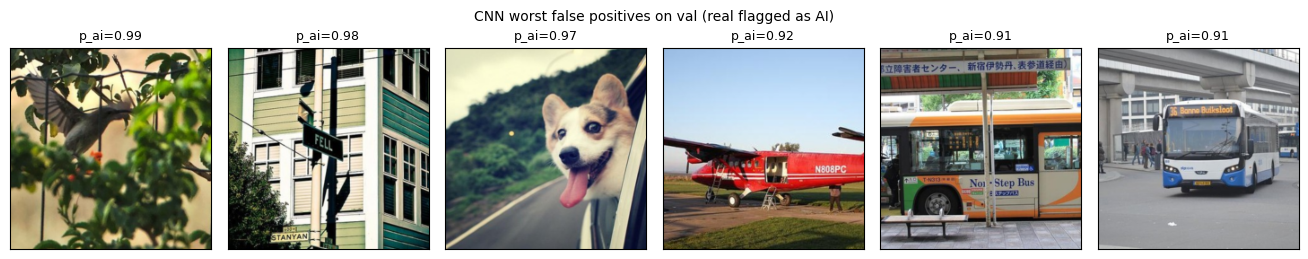

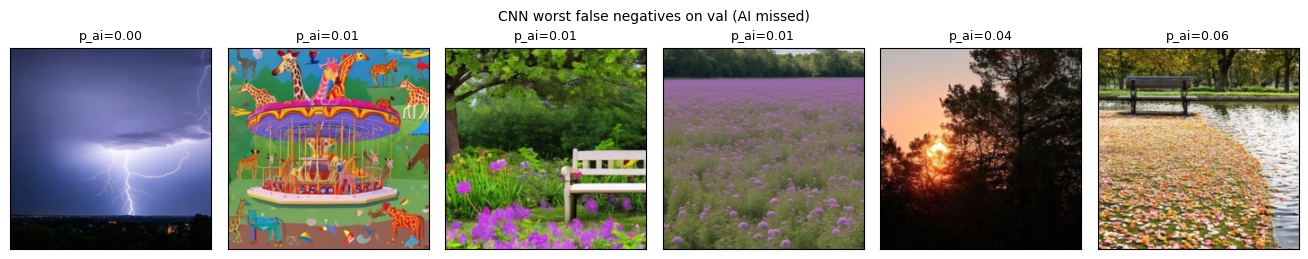

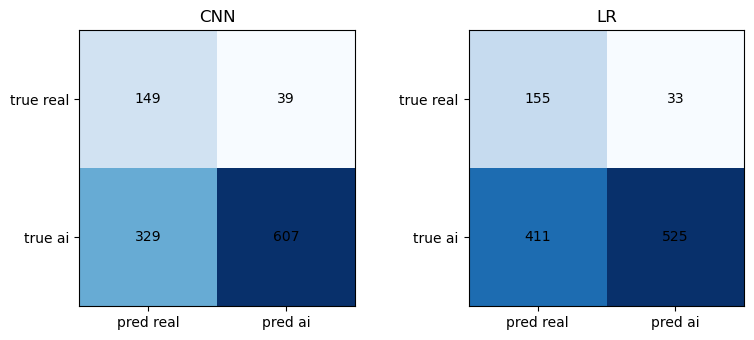

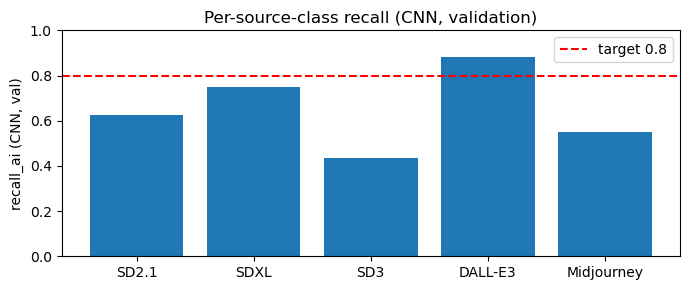

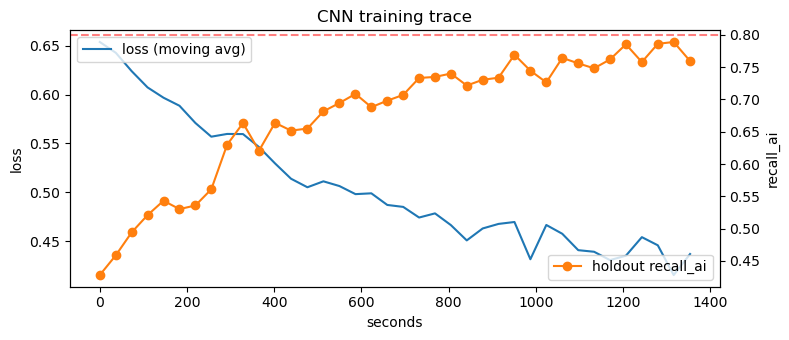

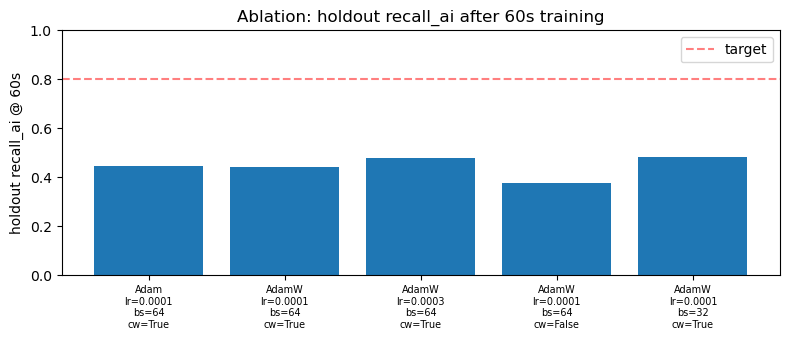

In [14]:
REPORT_FIG = ROOT / "report" / "figures"
REPORT_FIG.mkdir(parents=True, exist_ok=True)


def show_top(title, mask, scores, X_u8, order, n=6, save=None):
    pop_idx = np.where(mask)[0]
    if len(pop_idx) == 0:
        print(f"no {title}"); return
    pop_scores = scores[pop_idx]
    take = np.argsort(-pop_scores if order == "desc" else pop_scores)[:n]
    chosen = pop_idx[take]
    fig, axes = plt.subplots(1, len(chosen), figsize=(2.2 * len(chosen), 2.6))
    if len(chosen) == 1:
        axes = [axes]
    for ax, gi in zip(axes, chosen):
        ax.imshow(X_u8[gi]); ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(f"p_ai={scores[gi]:.2f}", fontsize=9)
    fig.suptitle(title, fontsize=10)
    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=150, bbox_inches="tight")
    plt.show()


mask_real = (y_val == 0)
mask_ai   = (y_val == 1)
show_top("CNN worst false positives on val (real flagged as AI)",
         mask_real, p_cnn_val, X_val, "desc", save=REPORT_FIG / "fig8_worst_fps.png")
show_top("CNN worst false negatives on val (AI missed)",
         mask_ai, p_cnn_val, X_val, "asc",  save=REPORT_FIG / "fig9_worst_fns.png")

fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
for ax, (label, p, thr) in zip(axes, [("CNN", p_cnn_val, thr_cnn), ("LR", p_lr_val, thr_lr)]):
    yp = (p >= thr).astype(int)
    cm = confusion_matrix(y_val, yp, labels=[0, 1])
    ax.imshow(cm, cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")
    ax.set_xticks([0, 1], ["pred real", "pred ai"])
    ax.set_yticks([0, 1], ["true real", "true ai"])
    ax.set_title(label)
plt.tight_layout()
plt.savefig(REPORT_FIG / "fig5_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

cnn_val_m = [m for tag, m in cnn_rows if tag == "val"][0]
pcr = cnn_val_m["per_source_class_recall"]
classes = list(range(1, 6))
fig, ax = plt.subplots(figsize=(7, 3))
ax.bar([CLASS_NAMES[c] for c in classes], [pcr[c] for c in classes])
ax.set_ylabel("recall_ai (CNN, val)")
ax.set_ylim(0, 1)
ax.axhline(0.8, color="red", linestyle="--", label="target 0.8")
ax.legend()
plt.title("Per-source-class recall (CNN, validation)")
plt.tight_layout()
plt.savefig(REPORT_FIG / "fig6_per_class_recall.png", dpi=150, bbox_inches="tight")
plt.show()

if history:
    fig, ax1 = plt.subplots(figsize=(8, 3.5))
    ts = [(h["t"] - history[0]["t"]) for h in history]
    ax1.plot(ts, [h["loss_ma"] for h in history], "C0-", label="loss (moving avg)")
    ax2 = ax1.twinx()
    ax2.plot(ts, [h["recall_ai"] for h in history], "C1-o", label="holdout recall_ai")
    ax2.axhline(0.8, color="red", linestyle="--", alpha=0.5)
    ax1.set_xlabel("seconds"); ax1.set_ylabel("loss"); ax2.set_ylabel("recall_ai")
    ax1.legend(loc="upper left"); ax2.legend(loc="lower right")
    plt.title("CNN training trace")
    plt.tight_layout()
    plt.savefig(REPORT_FIG / "fig4_training_trace.png", dpi=150, bbox_inches="tight")
    plt.show()

fig, ax = plt.subplots(figsize=(8, 3.5))
labels = [f"{r['optimizer']}\nlr={r['lr']}\nbs={r['batch']}\ncw={r['class_weight']}" for r in ablation_rows]
vals = [r.get("recall_ai", 0.0) for r in ablation_rows]
ax.bar(range(len(ablation_rows)), vals)
ax.set_xticks(range(len(ablation_rows)), labels, fontsize=7)
ax.axhline(0.8, color="red", linestyle="--", alpha=0.5, label="target")
ax.set_ylabel("holdout recall_ai @ 60s")
ax.set_ylim(0, 1)
plt.legend()
plt.title("Ablation: holdout recall_ai after 60s training")
plt.tight_layout()
plt.savefig(REPORT_FIG / "fig7_ablation.png", dpi=150, bbox_inches="tight")
plt.show()

## A.11 - Budget proof + A.12 exit criteria

In [15]:
print(f"reference         = {elapsed:.1f}s")
print(f"final CNN train   = {final_train_seconds:.1f}s")
print(f"ratio             = {final_train_seconds/elapsed:.2f}x  (must be <= 5)")
print(f"5x budget         = {BUDGET_S:.1f}s")
assert final_train_seconds <= BUDGET_S, f"OVER BUDGET: {final_train_seconds:.1f}s > {BUDGET_S:.1f}s"

cnn_val = [m for tag, m in cnn_rows if tag == "val"][0]
lr_val  = [m for tag, m in lr_rows  if tag == "val"][0]

print("\n=== Exit criteria (validation) ===")
print(f"CNN: recall_ai={cnn_val['recall_ai']:.3f}  fpr_real={cnn_val['fpr_real']:.3f}  "
      f"{'PASS' if cnn_val['recall_ai']>=0.8 and cnn_val['fpr_real']<=0.20 else 'FAIL'}")
print(f"LR:  recall_ai={lr_val['recall_ai']:.3f}  fpr_real={lr_val['fpr_real']:.3f}  "
      f"{'PASS' if lr_val['recall_ai']>=0.8 and lr_val['fpr_real']<=0.20 else 'FAIL'}")

def is_pass(m):
    return m["recall_ai"] >= 0.80 and m["fpr_real"] <= 0.20

candidates = []
if is_pass(cnn_val): candidates.append(("cnn", cnn_val))
if is_pass(lr_val):  candidates.append(("lr",  lr_val))
if candidates:
    winner = max(candidates, key=lambda kv: kv[1]["recall_ai"])
    print(f"\nWINNER: {winner[0]}  recall_ai={winner[1]['recall_ai']:.3f}")
else:
    print("\nWINNER: none -- exit criteria not met. Iterate before porting to scripts.")

reference         = 291.5s
final CNN train   = 1397.4s
ratio             = 4.79x  (must be <= 5)
5x budget         = 1457.3s

=== Exit criteria (validation) ===
CNN: recall_ai=0.649  fpr_real=0.207  FAIL
LR:  recall_ai=0.561  fpr_real=0.176  FAIL

WINNER: none -- exit criteria not met. Iterate before porting to scripts.
